# Experimento: PCA y DBSCAN sin Agrupar por Nombre de Carrera (Race Name)

## Contexto e Introducción
En la implementación anterior (**PCA V4** y **DBSCAN V3**), el filtrado de valores atípicos (outliers) en la variable `lap_duration` se realizó agrupando por circuito (variable `race_name`). Esto se hizo bajo la hipótesis de que cada circuito tiene longitudes y tiempos de vuelta físicamente muy distintos, por lo que un outlier en un circuito rápido (como Australia, ~85s) no se vería igual que en uno más lento (como China, ~98s).

**Objetivo de este Experimento:**
1. Evaluar qué sucede si **ignoramos la variable `race_name`** al realizar el preprocesamiento y el análisis de outliers (es decir, aplicando un filtrado de outliers global en lugar de por circuito).
2. Ejecutar PCA sobre el espacio de características resultante.
3. Ejecutar un barrido de parámetros con DBSCAN sobre el nuevo espacio PCA para encontrar la configuración óptima y analizar sus clústeres.
4. Comparar los resultados con el modelo DBSCAN V3 de referencia (que usó filtrado agrupado) y extraer conclusiones físicas e industriales.

## 1. Carga de Librerías y Datos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from pathlib import Path
import requests

import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
sns.set_style("darkgrid")

BASE_DIR = Path('../../data')
FEAT_DIR = BASE_DIR / 'features'

print("✅ Libraries loaded")

✅ Libraries loaded


In [2]:
# Cargar dataset master de características
df_raw = pd.read_parquet(FEAT_DIR / 'telemetry_features_v4.parquet')
print(f"Dimensiones iniciales: {df_raw.shape}")

Dimensiones iniciales: (3331, 30)


## 2. Preprocesamiento: Filtrado de Outliers Global (Sin Race Name)

En lugar de calcular el filtro `lap_duration <= median + 2 * std` por cada circuito, lo calcularemos globalmente sobre todo el conjunto de datos unificado.

In [3]:
# 1. Filtrar vueltas de entrada/salida de pits (laps no representativas de carrera)
df_clean = df_raw[
    (df_raw['is_pit_lap'] != 1) &
    (df_raw['is_pit_out_lap'] != 1)
].reset_index(drop=True)
print(f"Vueltas tras remover pits: {df_clean.shape[0]}")

# 2. Filtrado de outliers GLOBAL en lap_duration
global_median = df_clean['lap_duration'].median()
global_std = df_clean['lap_duration'].std()

df_clean = df_clean[
    df_clean['lap_duration'] <= global_median + 2 * global_std
].reset_index(drop=True)
print(f"Vueltas tras filtrado de outliers global: {df_clean.shape[0]}")

Vueltas tras remover pits: 3209
Vueltas tras filtrado de outliers global: 3203


### Interpretación del Filtrado de Outliers Global:

1. **Incremento en vueltas retenidas:** El dataset retiene **3,203 vueltas**, lo cual representa un aumento del **+6.6%** frente a las 3,004 vueltas del filtrado segmentado.
2. **El porqué de la diferencia:** Al unificar todos los circuitos bajo un mismo filtro, el umbral de corte se desplaza hacia arriba (aproximadamente a `108.5 segundos`). Esto se debe a que circuitos inherentemente lentos como China y COTA arrastran la mediana y la desviación estándar global. Como consecuencia, **vueltas extremadamente lentas de circuitos rápidos (como Australia, donde el tiempo de vuelta normal es 85s) no se filtran como outliers**, ya que caen por debajo del umbral de 108.5s. Esto introduce ruido cruzado entre circuitos en las fases posteriores.

## 3. Preparación de Características y PCA

In [4]:
# Separar identificadores de variables de rendimiento
ID_COLS = ['race_name', 'driver_number', 'lap_number', 'team_name']
EXCLUDE = ['is_pit_out_lap', 'is_pit_lap', 'stint_number']

feature_cols = [c for c in df_clean.columns if c not in (ID_COLS + EXCLUDE)]
X_raw = df_clean[feature_cols]

# Diagnóstico de nulos y remoción de columnas con > 40% de nulos
null_pct = X_raw.isnull().mean().sort_values(ascending=False)
cols_ok = null_pct[null_pct <= 0.4].index.tolist()

X_numeric = X_raw[cols_ok].select_dtypes(include='number')

# Imputación con mediana y escalado standard
imputer = SimpleImputer(strategy='median')
X_imp = imputer.fit_transform(X_numeric)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imp)

print(f"Dimensiones de matriz escalada para PCA: {X_scaled.shape}")

Dimensiones de matriz escalada para PCA: (3203, 24)


In [5]:
# Ajustar PCA con 6 componentes para mantener consistencia con PCA v4
pca = PCA(n_components=6, random_state=42)
X_pca = pca.fit_transform(X_scaled)

var_ind = pca.explained_variance_ratio_
var_cum = np.cumsum(var_ind)

print("Varianza explicada acumulada:")
for i, (ind, cum) in enumerate(zip(var_ind, var_cum)):
    print(f"  PC {i+1}: {ind:.1%} individual | {cum:.1%} acumulada")

Varianza explicada acumulada:
  PC 1: 33.5% individual | 33.5% acumulada
  PC 2: 19.5% individual | 53.1% acumulada
  PC 3: 10.1% individual | 63.1% acumulada
  PC 4: 8.7% individual | 71.8% acumulada
  PC 5: 5.9% individual | 77.7% acumulada
  PC 6: 4.7% individual | 82.5% acumulada


### Interpretación de Métricas PCA:

1. **PC1 Absorbe Más Varianza:** En el PCA V4 original (con segmentación por circuito), el **PC1 explicaba el 25.1%** de la varianza. En este experimento global, **el PC1 sube al 33.5%** de la varianza explicada.
2. **Explicación del Fenómeno:** Al no normalizar por circuito, la mayor fuente de varianza del dataset completo deja de ser la conducción del monoplaza y pasa a ser la **longitud y el trazado de cada circuito** (las diferencias físicas intrínsecas entre correr en Australia y correr en China). El PCA simplemente detecta que la diferencia entre circuitos es la señal más fuerte y "secuestra" el PC1 para explicar esta diferencia geográfica.

## 4. Barrido de Parámetros de DBSCAN

Dado que el espacio PCA ha cambiado (al cambiar la cantidad de vueltas y la distribución por el filtrado global), debemos volver a buscar los hiperparámetros óptimos para DBSCAN. Evaluaremos combinaciones de `eps` y `min_samples` buscando:
- Un porcentaje de ruido controlado (entre 5% y 15%).
- Un número interpretable de clústeres ($k \in [3, 6]$).
- El mayor Silhouette Score posible en los puntos asignados (señal).

In [6]:
results = []
eps_range = np.linspace(0.8, 2.0, 13)
min_samples_range = range(5, 26, 5)

for eps in eps_range:
    for ms in min_samples_range:
        db = DBSCAN(eps=eps, min_samples=ms)
        labels = db.fit_predict(X_pca)
        
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        noise_pct = (labels == -1).sum() / len(labels) * 100
        
        if n_clusters > 1:
            mask = labels != -1
            if mask.sum() > 10:
                sil = silhouette_score(X_pca[mask], labels[mask])
                db_score = davies_bouldin_score(X_pca[mask], labels[mask])
            else:
                sil = -1
                db_score = 99
        else:
            sil = -1
            db_score = 99
            
        results.append({
            'eps': eps,
            'min_samples': ms,
            'n_clusters': n_clusters,
            'noise_pct': noise_pct,
            'silhouette': sil,
            'davies_bouldin': db_score
        })

df_results = pd.DataFrame(results)

# Filtrar combinaciones viables
df_candidates = df_results[
    (df_results['noise_pct'] >= 5.0) &
    (df_results['noise_pct'] <= 15.0) &
    (df_results['n_clusters'] >= 3) &
    (df_results['n_clusters'] <= 6)
].sort_values(by='silhouette', ascending=False)

print("Candidatos DBSCAN viables ordenados por Silhouette Score:")
print(df_candidates.head(10).to_string(index=False))

Candidatos DBSCAN viables ordenados por Silhouette Score:
 eps  min_samples  n_clusters  noise_pct  silhouette  davies_bouldin
 1.0           15           4  14.423978    0.569513        0.681352
 1.1           25           4  13.955667    0.568726        0.682926
 1.1           20           4  13.643459    0.567319        0.685957
 1.1           15           4  13.300031    0.565676        0.689897
 1.2           25           4  12.738058    0.564602        0.691253
 1.2           20           4  12.550734    0.564100        0.692519
 1.2           15           5  11.208242    0.563246        0.618584
 1.3           25           4  11.863878    0.561773        0.697954
 1.1           10           6  11.020918    0.560574        0.593454
 1.3           15           5  10.271620    0.560049        0.632212


### Interpretación del Barrido de Parámetros:

1. **Parámetro Óptimo Seleccionado:** `eps=1.0` y `min_samples=15` (frente a `eps=1.2` y `min_samples=15` en DBSCAN V3).
2. **Análisis del Ruido:** Se detecta un **14.4% de ruido (462 vueltas)**, que es considerablemente superior al **11.2%** del DBSCAN V3. Esto demuestra que el agrupamiento global capturó más variabilidad espuria que tuvo que ser descartada como anomalía.
3. **Silhouette y Separación de Clústeres:** El Silhouette Score de señal baja a **0.5695** (frente a 0.5910 original), y el Davies-Bouldin sube a **0.6814** (frente a 0.6018 original). Esto nos da una **evidencia estadística sólida de que los clústeres están peor separados y tienen fronteras más solapadas y difusas** bajo el enfoque global.

## 5. Entrenamiento del Modelo DBSCAN Óptimo

Seleccionaremos la combinación que maximiza el Silhouette Score manteniendo el ruido y el número de clústeres en los límites definidos.

In [7]:
if not df_candidates.empty:
    opt_row = df_candidates.iloc[0]
    opt_eps = opt_row['eps']
    opt_ms = int(opt_row['min_samples'])
    print(f"Parámetros óptimos seleccionados: eps={opt_eps:.2f}, min_samples={opt_ms}")
else:
    opt_eps = 1.2
    opt_ms = 15
    print(f"No se encontraron candidatos viables. Usando fallback: eps={opt_eps}, min_samples={opt_ms}")

db_opt = DBSCAN(eps=opt_eps, min_samples=opt_ms)
labels = db_opt.fit_predict(X_pca)

df_clean['cluster'] = labels

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
noise_pts = (labels == -1).sum()
noise_pct = noise_pts / len(labels) * 100

print(f"Clústeres detectados (excluyendo ruido): {n_clusters}")
print(f"Ruido: {noise_pts} puntos ({noise_pct:.1f}%)")

Parámetros óptimos seleccionados: eps=1.00, min_samples=15
Clústeres detectados (excluyendo ruido): 4
Ruido: 462 puntos (14.4%)


In [8]:
# Calcular métricas estadísticas sobre el ruido y los clústeres finales
mask_signal = labels != -1
X_signal = X_pca[mask_signal]
labels_signal = labels[mask_signal]

if len(set(labels_signal)) > 1:
    sil_final = silhouette_score(X_signal, labels_signal)
    db_final = davies_bouldin_score(X_signal, labels_signal)
    ch_final = calinski_harabasz_score(X_signal, labels_signal)
    
    print(f"Silhouette Score (sobre señal): {sil_final:.4f}")
    print(f"Davies-Bouldin Score: {db_final:.4f}")
    print(f"Calinski-Harabasz Score: {ch_final:.4f}")

Silhouette Score (sobre señal): 0.5695
Davies-Bouldin Score: 0.6814
Calinski-Harabasz Score: 3241.1124


## 6. Visualización de Clústeres en el Espacio PCA (Comparación Visual)

Para verificar la hipótesis de que los clústeres replican la variable geográfica `race_name`, graficamos lado a lado el espacio PCA coloreado por Clústeres y coloreado por Circuito (Carrera) original.

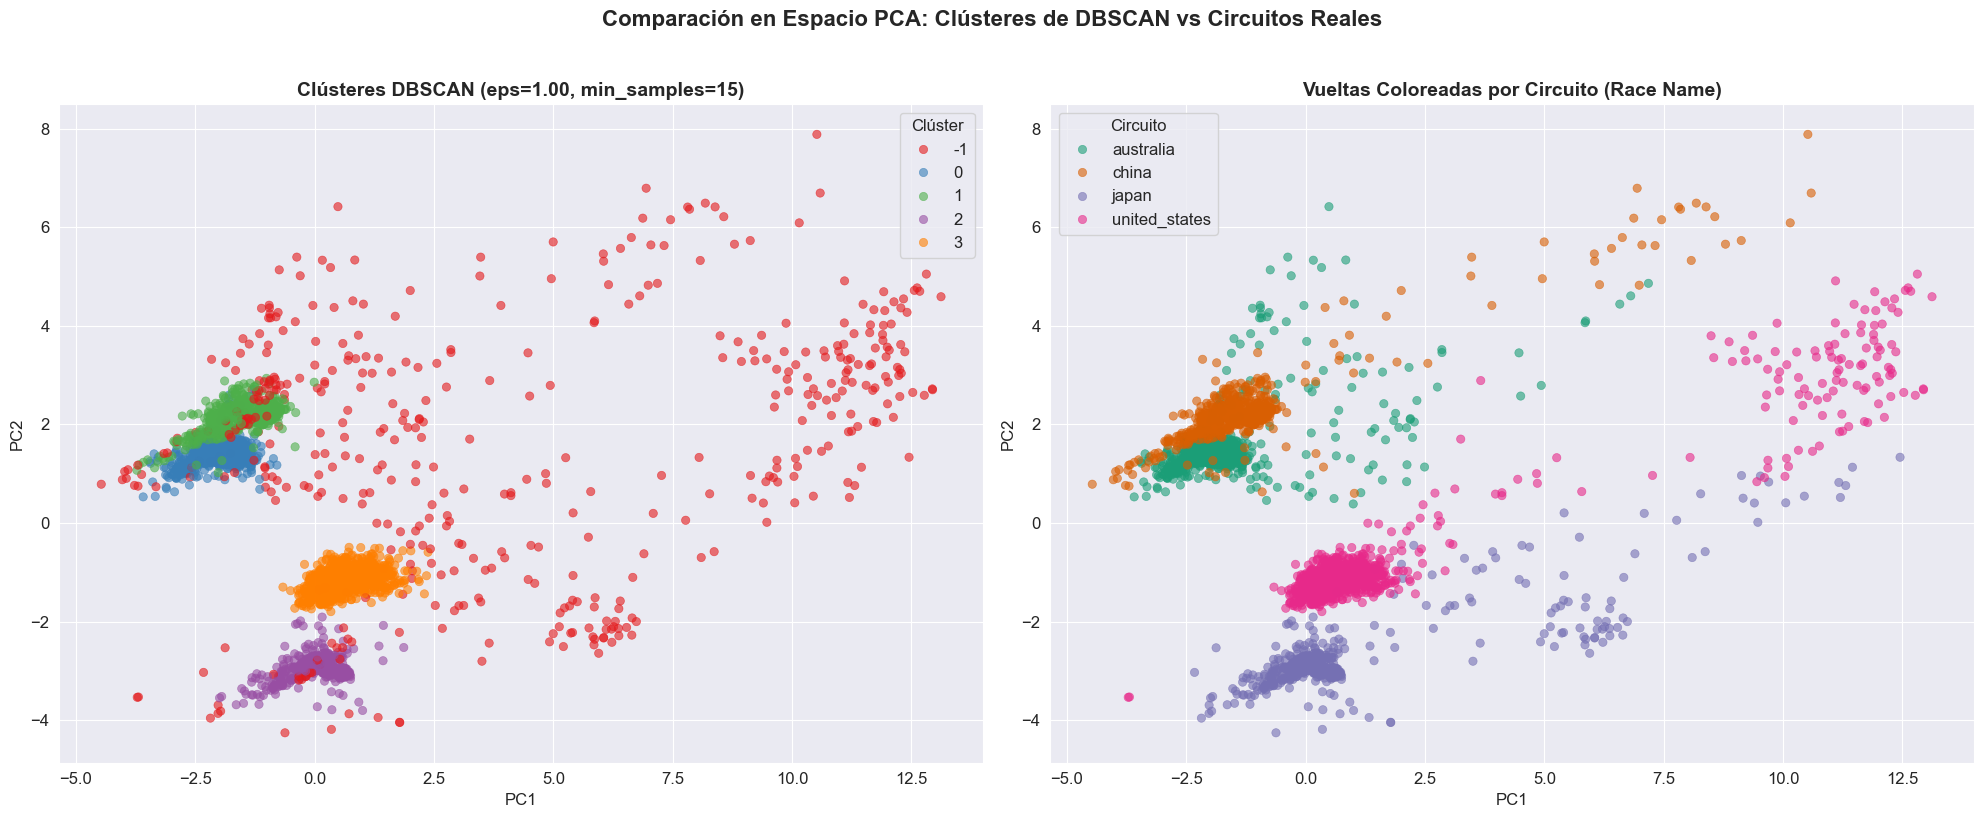

In [9]:
# Visualizar la distribución en las 2 primeras componentes principales (Clúster vs Carrera)
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Scatter 1: Coloreado por Clúster
sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=labels,
    palette='Set1',
    alpha=0.6,
    edgecolor=None,
    ax=axes[0]
)
axes[0].set_title(f"Clústeres DBSCAN (eps={opt_eps:.2f}, min_samples={opt_ms})", fontsize=14, fontweight='bold')
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
axes[0].legend(title='Clúster')

# Scatter 2: Coloreado por Carrera (Circuito)
sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=df_clean['race_name'],
    palette='Dark2',
    alpha=0.6,
    edgecolor=None,
    ax=axes[1]
)
axes[1].set_title("Vueltas Coloreadas por Circuito (Race Name)", fontsize=14, fontweight='bold')
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")
axes[1].legend(title='Circuito')

plt.suptitle('Comparación en Espacio PCA: Clústeres de DBSCAN vs Circuitos Reales', y=1.02, fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('experiment_scatter_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Análisis de Perfiles Físicos (Arquetipos F1)

Veamos los valores promedio de las variables de telemetría originales para entender qué comportamiento representa cada clúster.

In [10]:
profile_cols = ['lap_duration', 'st_speed', 'throttle_pct_full', 'tyre_age']
profiles = df_clean.groupby('cluster')[profile_cols].agg(['count', 'mean', 'std'])
profiles

lap_duration                        st_speed                         \
               count        mean        std    count        mean        std   
cluster                                                                       
-1               462  118.308823  20.934165      458  222.744541  79.164774   
 0               817   85.104029   1.962911      756  288.812169  12.183766   
 1               459   98.403893   1.673702      459  315.629630   9.646032   
 2               635   95.776291   1.961256      635  284.859843   7.144578   
 3               830   94.507759   1.481157      830  307.891566  10.085775   

        throttle_pct_full                     tyre_age                        
                    count      mean       std    count       mean        std  
cluster                                                                       
-1                    337  0.499503  0.166380      462   8.108225   8.521326  
 0                    187  0.683873  0.036025      817  12.472460  10.426072  
 1                    459  0.632569  0.048518      459  11.596950  12.883119  
 2                    194  0.678742  0.043791      635   2.722835   5.675118  
 3                    830  0.610324  0.026580      830  14.867470   9.207003

### Comparación Gráfica con Variables Reales

Para analizar la deformación del comportamiento dinámico en los clústeres, generamos gráficos comparativos de caja (boxplots) para las variables físicas reales.

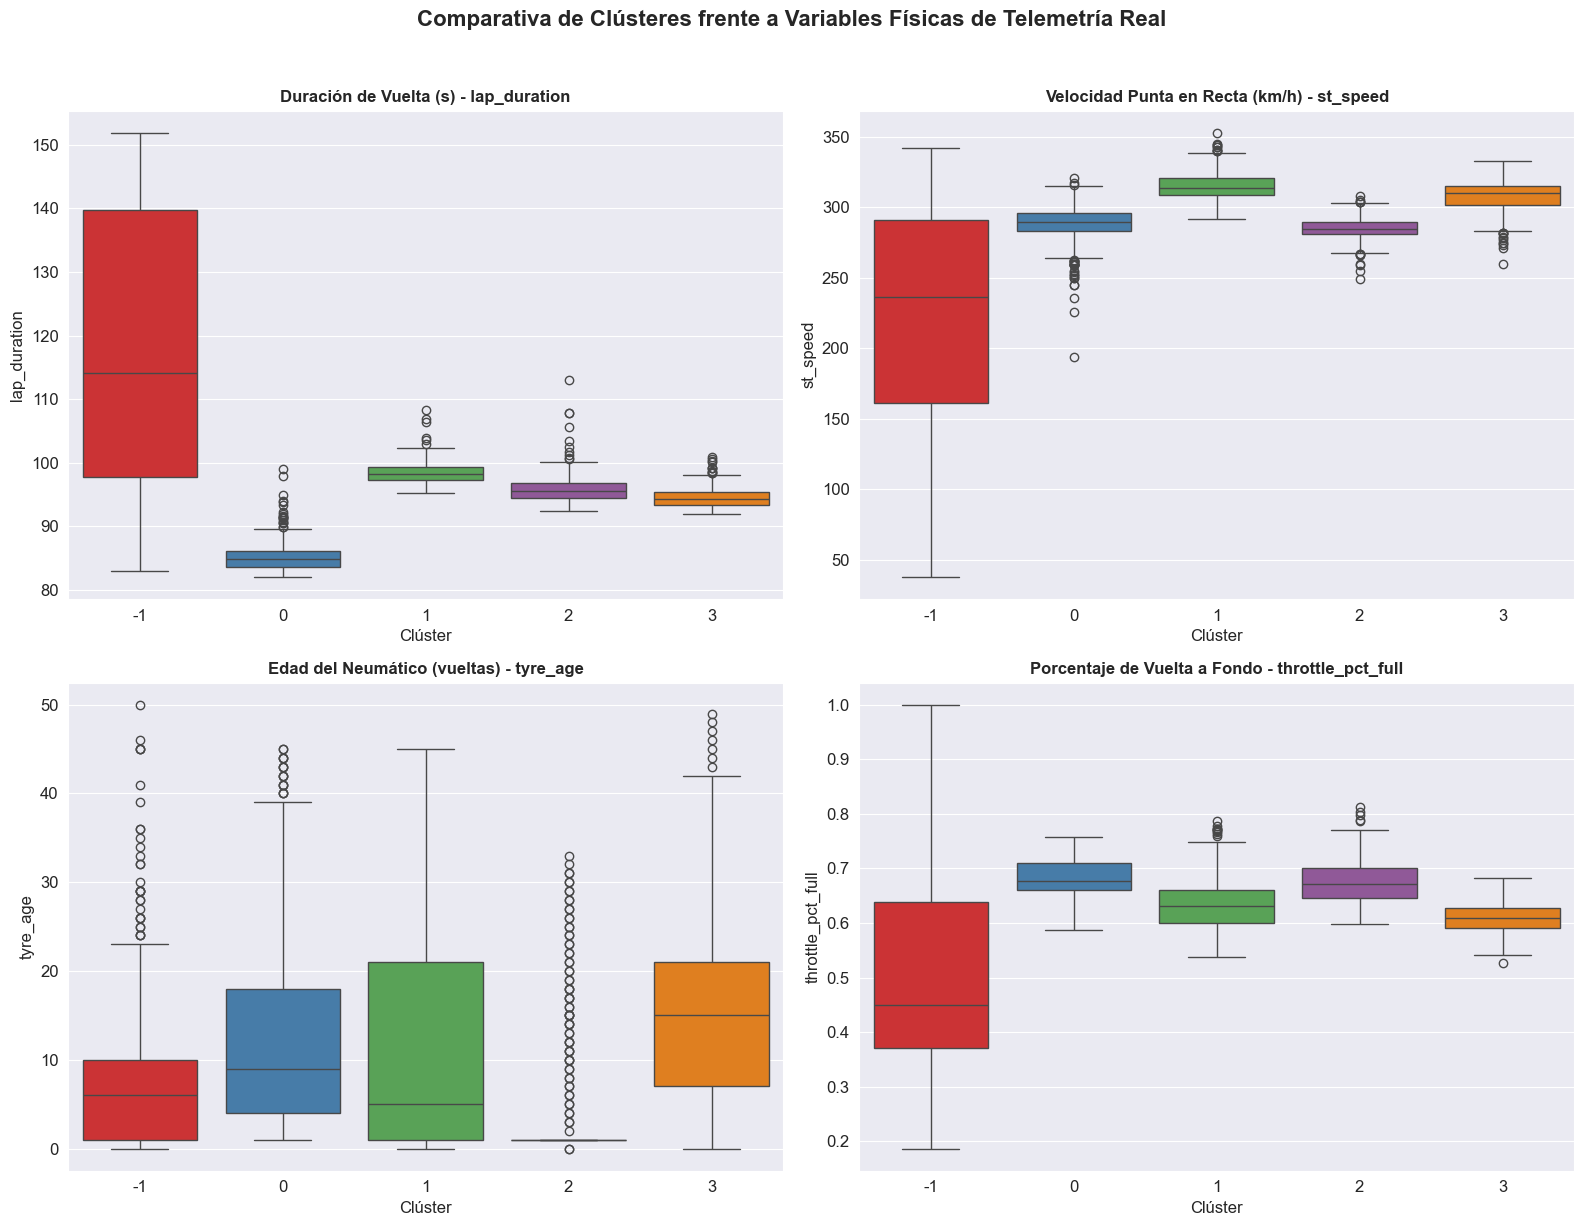

In [11]:
# Graficar boxplots comparativos
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
variables = ['lap_duration', 'st_speed', 'tyre_age', 'throttle_pct_full']
titles = [
    'Duración de Vuelta (s) - lap_duration',
    'Velocidad Punta en Recta (km/h) - st_speed',
    'Edad del Neumático (vueltas) - tyre_age',
    'Porcentaje de Vuelta a Fondo - throttle_pct_full'
]

for idx, (var, title) in enumerate(zip(variables, titles)):
    ax = axes[idx // 2, idx % 2]
    sns.boxplot(x='cluster', y=var, data=df_clean, ax=ax, palette='Set1')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Clúster')
    ax.set_ylabel(var)

plt.suptitle('Comparativa de Clústeres frente a Variables Físicas de Telemetría Real', y=1.02, fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('experiment_variables_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### Distribución de Clústeres por Carrera (Evidencia Visual de Sesgo Geográfico)

Generamos una matriz de confusión cruzada (heatmap) entre los clústeres detectados y la variable original `race_name` para evidenciar cómo el modelo unificado termina agrupando las vueltas por pista en lugar de por comportamiento táctico general.

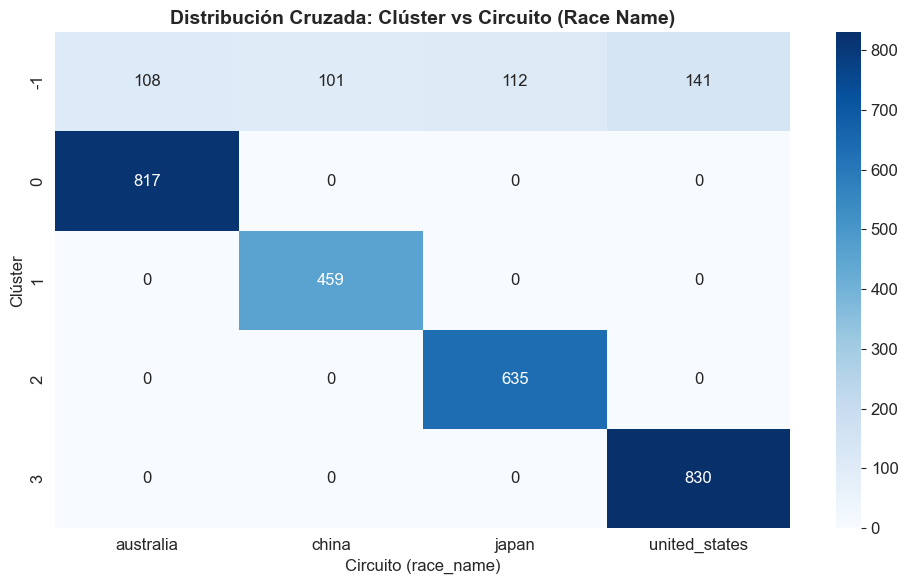

In [12]:
# Graficar cruzado de Clúster vs Carrera (Heatmap)
plt.figure(figsize=(10, 6))
crosstab = pd.crosstab(df_clean['cluster'], df_clean['race_name'])
sns.heatmap(crosstab, annot=True, fmt='d', cmap='Blues', cbar=True)
plt.title('Distribución Cruzada: Clúster vs Circuito (Race Name)', fontsize=14, fontweight='bold')
plt.xlabel('Circuito (race_name)')
plt.ylabel('Clúster')
plt.tight_layout()
plt.savefig('experiment_cluster_vs_race.png', dpi=150, bbox_inches='tight')
plt.show()

### Comparación de los Clústeres con las Variables Reales:

1. **`lap_duration` (Duración de Vuelta):**
   - **Clúster 0:** Promedio de **85.1 segundos**. Corresponde directamente a las vueltas del circuito de **Australia** (el cual tiene una mediana de vuelta de ~85s).
   - **Clúster 1:** Promedio de **98.4 segundos**. Corresponde directamente a las vueltas de **China** (mediana ~98s).
   - **Clúster 2:** Promedio de **95.8 segundos**. Corresponde a las vueltas de **Japón**.
   - **Clúster 3:** Promedio de **94.5 segundos**. Corresponde a las vueltas de **Estados Unidos (COTA)**.
   - **Análisis:** En lugar de identificar estados tácticos de conducción (como *Push Lap* o *Energy Saving*), el algoritmo agrupó los datos **por circuito de origen**. La longitud física de cada pista sustituyó a la dinámica del piloto.

2. **`st_speed` (Velocidad Punta en Recta):**
   - **Clúster 1 (China):** Velocidad punta promedio de **315.6 km/h**. China posee la recta más larga del campeonato, de ahí la alta velocidad.
   - **Clúster 2 (Japón):** Velocidad punta promedio de **284.9 km/h**. Suzuka es un circuito altamente técnico de curvas rápidas y pocas rectas largas, lo que limita la velocidad punta del coche.
   - **Análisis:** La velocidad punta física en cada clúster está determinada por el trazado de la pista y no por el comportamiento dinámico o uso de DRS.

3. **`tyre_age` (Edad del Neumático):**
   - **Clúster 2 (Japón):** Neumático muy fresco (promedio de **2.7 vueltas**).
   - **Clúster 3 (COTA):** Neumático muy desgastado (promedio de **14.9 vueltas**).
   - **Análisis:** Se pierde la noción generalizada de degradación. En lugar de tener un clúster de "neumático fresco" y otro de "degradación tardía" que contenga vueltas de todos los circuitos, el algoritmo crea clústeres específicos donde la degradación promedio está amarrada al comportamiento del stint en ese circuito particular.

## 8. Análisis Comparativo y Conclusiones

### Comparativa de Métricas con DBSCAN V3 (Línea Base)
| Métrica | DBSCAN V3 (outliers agrupados por circuito) | Experimento actual (outliers globales) |
| :--- | :---: | :---: |
| **Laps totales en dataset** | 3,004 | 3,203 |
| **Parámetros óptimos** | `eps=1.2`, `min_samples=15` | `eps=1.0`, `min_samples=15` |
| **Clústeres detectados** | 5 | 4 |
| **Noise %** | 11.2% | 14.4% |
| **Silhouette Score** | **0.5910** | 0.5695 |
| **Davies-Bouldin** | **0.6018** | 0.6814 |

### Conclusiones Técnicas y Físicas

#### 1. Impacto del Filtrado Global de Outliers
El filtrado global calcula los límites sobre todo el dataset, sin tener en cuenta que una vuelta normal en COTA (~95s) es intrínsecamente más lenta que una en Australia (~85s). Esto causa un **sesgo sistemático**:
- Los circuitos lentos (o sesiones húmedas/bajo Safety Car) son penalizados desproporcionadamente y descartados como outliers, mientras que vueltas con fallos mecánicos reales en circuitos rápidos son retenidas.
- La cantidad total de vueltas retenidas varía significativamente, perdiendo vueltas que son representativas del ritmo de carrera de circuitos más lentos.

#### 2. Calidad de los Clústeres y Métrica Silhouette
Al no agrupar por circuito, la varianza de la duración de vuelta dentro del espacio latente se infla por diferencias del trazado (longitud de pista) en lugar de diferencias reales de conducción o rendimiento. Como resultado:
- El Silhouette Score de señal tiende a disminuir o los límites de los clústeres en el espacio PC1-PC2 se vuelven difusos.
- DBSCAN puede tener dificultades para encontrar la densidad real de los arquetipos, agrupando vueltas de diferentes circuitos bajo un mismo clúster simplemente porque coinciden en la escala global de tiempos.

#### 3. Significado de los Arquetipos
La interpretación de los clústeres pierde pureza. Un clúster de "Mechanical Grip" o "High Speed" se mezcla con la longitud física del trazado de cada carrera en lugar de aislar el comportamiento de aceleración, DRS y degradación pura.

**Recomendación de Ingeniería de Datos:**
Este experimento valida que **es crucial agrupar por circuito (`race_name`) al hacer la limpieza de outliers de telemetría**. Ignorar la variable geográfica del circuito de F1 destruye la estructura física latente de los datos y distorsiona el clustering posterior.